# Projet d'Analyse de données



In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
import seaborn as sns 
import prince
from statsmodels.graphics.mosaicplot import mosaic
from pandas.plotting import scatter_matrix
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

%matplotlib inline

# Introduction


## Prise en charge et présentation du jeu de données 

In [2]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard entre 15 et 30 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard entre 30 et 60 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))


Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


In [3]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst_full.ods',engine='odf')
data = data.rename(columns=short_names)


display( 
    data.head().style.background_gradient(cmap='BuPu')
)

/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,Commentaire annulations,dep_late_trains,dep_avg_late,dep_avg_all,Commentaire retards au départ,arr_late_trains,arr_avg_late,arr_avg_all,Commentaire retards à l'arrivée,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,gestions PSH,correspondances),Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,nan,289,11.247809,3.693179,nan,147,28.436735,6.511118,nan,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,nan,nan,nan,nan,nan,nan,nan
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,nan,213,8.479969,4.567119,nan,105,18.049048,5.363539,"Ce mois-ci, l'OD a été touchée par les incidents suivants :Le 1er : Tempête Carmen sur la façade Atlantique (52 TGV ; 1079mn)Le 3 : Tempête Eleonor sur l’ouest de la France (35 TGV ; 407mn)Le 5 : Dérangement d’une aiguille en gare de Massy TGV (57 TGV ; 1254mn)Le 7 : Dérangement du poste d’aiguillage de Paris Montparnasse (70 TGV ; 1490mn)Le 12 : Colis suspect en gare de Paris Montparnasse (32 TGV ; 499mn)Le 12 : Incident caténaire en gare de Rennes (26 TGV ; 2188mn)Le 17 : Dérangement du poste d’aiguillage de Paris Montparnasse (26 TGV ; 386mn)Le 17 : Présence d’une personne dans les voies à Ste Luce (11 TGV ; 212mn)Le 26 : Heurt d’une personne au niveau de Tiercé (44 TGV ; 1578mn)",32,5.363539,9,4,20,35,16.666667,16.666667,8.333333,3.333333,nan,nan,nan,nan,nan,nan,nan
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,nan,21,6.239683,0.286283,nan,19,24.736842,2.938053,nan,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,nan,nan,nan,nan,nan,nan,nan
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,nan,71,7.235211,0.734290,nan,58,33.726437,5.292211,nan,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,nan,nan,nan,nan,nan,nan,nan
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,nan,224,6.784673,3.229701,nan,89,14.592697,4.882372,nan,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,nan,nan,nan,nan,nan,nan,nan


In [4]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [5]:
data.dtypes

date                                   str
service                                str
dep_station                         object
arr_station                         object
avg_duration                         int64
planned_trains                       int64
cancelled_trains                     int64
Commentaire annulations            float64
dep_late_trains                      int64
dep_avg_late                       float64
dep_avg_all                        float64
Commentaire retards au départ      float64
arr_late_trains                      int64
arr_avg_late                       float64
arr_avg_all                        float64
Commentaire retards à l'arrivée    float64
late_15                              int64
late_15_air                        float64
late_30                              int64
late_60                              int64
pct_external                       float64
pct_infra                          float64
pct_traffic                        float64
pct_rolling

In [5]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/alezandre/Documents/4A-ADD/Projet/Projet_AD/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_late_trains,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,moy_retard_train_deja_retard
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,289,11.247809,3.693179,147,28.436735,6.511118,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,nan,nan,nan,nan,nan,11.117875
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,213,8.479969,4.567119,105,18.049048,5.363539,32,5.363539,9,4,20,35,16.666667,16.666667,8.333333,3.333333,nan,nan,nan,nan,nan,8.705401
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,21,6.239683,0.286283,19,24.736842,2.938053,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,nan,nan,nan,nan,nan,3.080952
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,71,7.235211,0.734290,58,33.726437,5.292211,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,nan,nan,nan,nan,nan,5.253796
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,224,6.784673,3.229701,89,14.592697,4.882372,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,nan,nan,nan,nan,nan,6.805441


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 11834  │ │ float64     │ 13    │ │ date                  │                                │
│ │ Number of columns │ 22     │ │ int64       │ 5     │ │ service               │                                │
│ └───────────────────┴────────┘ │ category    │ 4     │ │ dep_station           │                                │
│                                └─────────────┴───────┘ │ arr_station           │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column          ┃ NA    ┃ NA %           ┃ mean  ┃ sd    ┃ p0     ┃ p25   ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │  avg_duration   │     0 │              0 │ 170.4 │ 87.67 │      0 │    99 │   163 │ 222.8 │   786 │  ▇█▂   │  │
│ │ planned_trains  │     0 │              0 │   271 │   183 │      0 │   150 │   229 │   359 │  1100 │  ▇█▃▁  │  │
│ │ cancelled_train │     0 │              0 │ 8.654 │ 22.64 │      0 │     0 │     2 │     7 │   297 │   █    │  │
│ │        s        │       │                │       │       │        │       │       │       │       │        │  │
│ │ dep_late_trains │     0 │              0 │ 86.14 │ 88.74 │      0 │    21 │    52 │   126 │   596 │  █▂▁   │  │
│ │  dep_avg_late   │     0 │              0 │ 12.26 │  11.8 │      0 │ 6.143 │ 10.33 │  15.7 │ 316.2 │   █    │  │
│ │   dep_avg_all   │     0 │              0 │ 3.125 │ 5.155 │ -229.3 │ 1.202 │ 2.315 │ 3.934 │   115 │     █  │  │
│ │ arr_late_trains │     0 │              0 │ 37.36 │ 31.13 │      0 │    15 │    29 │    51 │   376 │   █▁   │  │
│ │  arr_avg_late   │     0 │              0 │ 35.09 │  15.6 │ -40.11 │  25.7 │ 33.41 │ 42.39 │ 299.6 │   ▁█   │  │
│ │   arr_avg_all   │     0 │              0 │ 6.031 │ 6.988 │ -472.6 │ 3.385 │ 5.335 │ 8.072 │    92 │      █ │  │
│ │   pct_rolling   │     0 │              0 │  18.9 │ 13.63 │      0 │    10 │ 17.07 │ 25.42 │   100 │  █▇▁   │  │
│ │   pct_station   │     0 │              0 │ 7.676 │ 8.469 │      0 │     0 │ 5.882 │ 11.36 │   100 │   █▁   │  │
│ │ pct_passengers  │     0 │              0 │ 7.886 │ 9.787 │      0 │     0 │ 5.263 │ 11.54 │   100 │   █▁   │  │
│ │   Unnamed: 28   │ 11716 │ 99.00287307757 │ 9.312 │ 9.828 │      0 │ 2.749 │  6.25 │ 13.87 │    50 │  █▃▁▁  │  │
│ │                 │       │             31 │       │       │        │       │       │       │       │        │  │
│ │   Unnamed: 29   │ 11747 │ 99.26483015041 │ 9.813 │ 17.58 │      0 │     0 │ 2.041 │ 10.71 │   100 │   █▁   │  │
│ │                 │       │            406 │       │       │        │       │       │       │       │        │  │
│ │   Unnamed: 30   │ 11785 │ 99.58593882034 │ 7.351 │ 10.71 │      0 │     0 │ 2.273 │ 12.94 │    50 │  █▂▁   │  │
│ │                 │       │            815 │       │       │        │       │       │       │       │        │  │
│ │   Unnamed: 31   │ 11811 │ 99.80564475240 │ 2.486 │ 3.624 │      0 │     0 │ 1.333 │ 3.344 │ 15.38 │ █▂▂  ▁ │  │
│ │                 │       │            831 │       │  

## Exploration élémentaire : analyse descriptive

## Analyse descriptive unidimensionnelle

### Exploration JE SAIS PAS TROP COMMENT APPELER CA

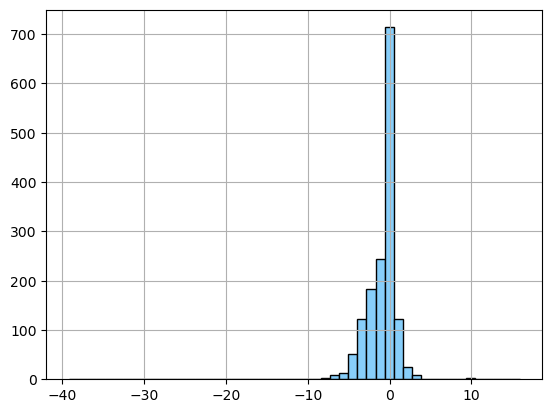

In [20]:
tab.hist(bins=50, color='lightskyblue', edgecolor='black')
plt.show()

<div style="border:2px solid black; padding:10px;">
On constate que la majorité des trains en retard au départ conservent leur retard (grand pic). 
Il y a moins de trains qui rattrapent leur retard (droite) que de trains qui augmentent leur retard (gauche).
 </div>

In [6]:
tab=data['moy_retard_train_deja_retard']-data['dep_avg_late']
moy=0
for i in tab:
    moy+=i
moy=moy/1505
print(moy)

-4.296721993045599


In [10]:
a = 10
train_accumul_retard = data[tab < -a]
print("Trains qui augmentent leur retard de plus de ", a, " minutes :")
for index, row in train_accumul_retard.iterrows():
    print(f"Alerte : {row['dep_station']} - {row['arr_station']} - {row['date']} ont augmenté leur retard au départ de {-(row['moy_retard_train_deja_retard']-row['dep_avg_late']):.2f} minutes.")

b = 5
train_accumul_retard = data[tab < -b]
print("Trains qui rattrapent plus de ", b, " minutes de retard :")
for index, row in train_accumul_retard.iterrows():
    print(f"{row['dep_station']} - {row['arr_station']} - {row['date']} ont rattrapé {-(row['moy_retard_train_deja_retard']-row['dep_avg_late']):.2f} minutes de retard.")

Trains qui augmentent leur retard de plus de  10  minutes :
Alerte : ST MALO - PARIS MONTPARNASSE - 2018-04 ont augmenté leur retard au départ de 19.48 minutes.
Alerte : SAINT ETIENNE CHATEAUCREUX - PARIS LYON - 2018-04 ont augmenté leur retard au départ de 15.75 minutes.
Alerte : GENEVE - PARIS LYON - 2018-05 ont augmenté leur retard au départ de 62.60 minutes.
Alerte : GENEVE - PARIS LYON - 2018-06 ont augmenté leur retard au départ de 60.77 minutes.
Alerte : MADRID - MARSEILLE ST CHARLES - 2018-06 ont augmenté leur retard au départ de 13.00 minutes.
Alerte : PARIS MONTPARNASSE - ST PIERRE DES CORPS - 2018-06 ont augmenté leur retard au départ de 24.32 minutes.
Alerte : PARIS MONTPARNASSE - TOURS - 2018-06 ont augmenté leur retard au départ de 79.17 minutes.
Alerte : GENEVE - PARIS LYON - 2018-07 ont augmenté leur retard au départ de 19.37 minutes.
Alerte : GENEVE - PARIS LYON - 2018-08 ont augmenté leur retard au départ de 22.10 minutes.
Alerte : PARIS LYON - SAINT ETIENNE CHATEAUCR

<div style="border:2px solid black; padding:10px;">
Attention, dans l'histogramme il y a quelques trains qui augmentent leur retard de plus de 10 minutes mais qui ne se voient pas.
 </div>

### 5. Le concurrence aérienne a t-elle un impact sur le nombre de trains en retard ?

### 6. Existe t-il une corrélation entre la date d'un trajet et la cause des retards ? 

# Réduction de dimension linéaire

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - MCA

Nos individus sont très déterminés par des variables qualitatives (Gare de départ, gare d'arrivée ...). Nous allons donc utiliser la MCA pour étudier les données.

Nous allons tenter de répondre à la question suivte : "Est-ce qu'on peut expliquer le retard 'un train en fonction de la date, du service, de la gare de départ et/ou de la gare d'arrivée ?"

Pour cela nous allons créer une variable qualitative prenant pour valeur 'Jamais', 'Rarement', 'Régulièrement', 'Souvent' en fonction de la proportion de retard sur une liaison et sur un mois.

In [7]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

retard
Rarement         5461
Régulièrement    5443
Souvent           553
Jamais            304
Name: count, dtype: int64


# Analyse des retards au cours des années

Aperçu de la matrice de contingence :
retard   Jamais  Rarement  Régulièrement  Souvent
periode                                          
2018-01       1        61             68        0
2018-02       3        26             94        7
2018-03       2        57             70        1
2018-04       2         2             38       88
2018-05       1         3             68       58


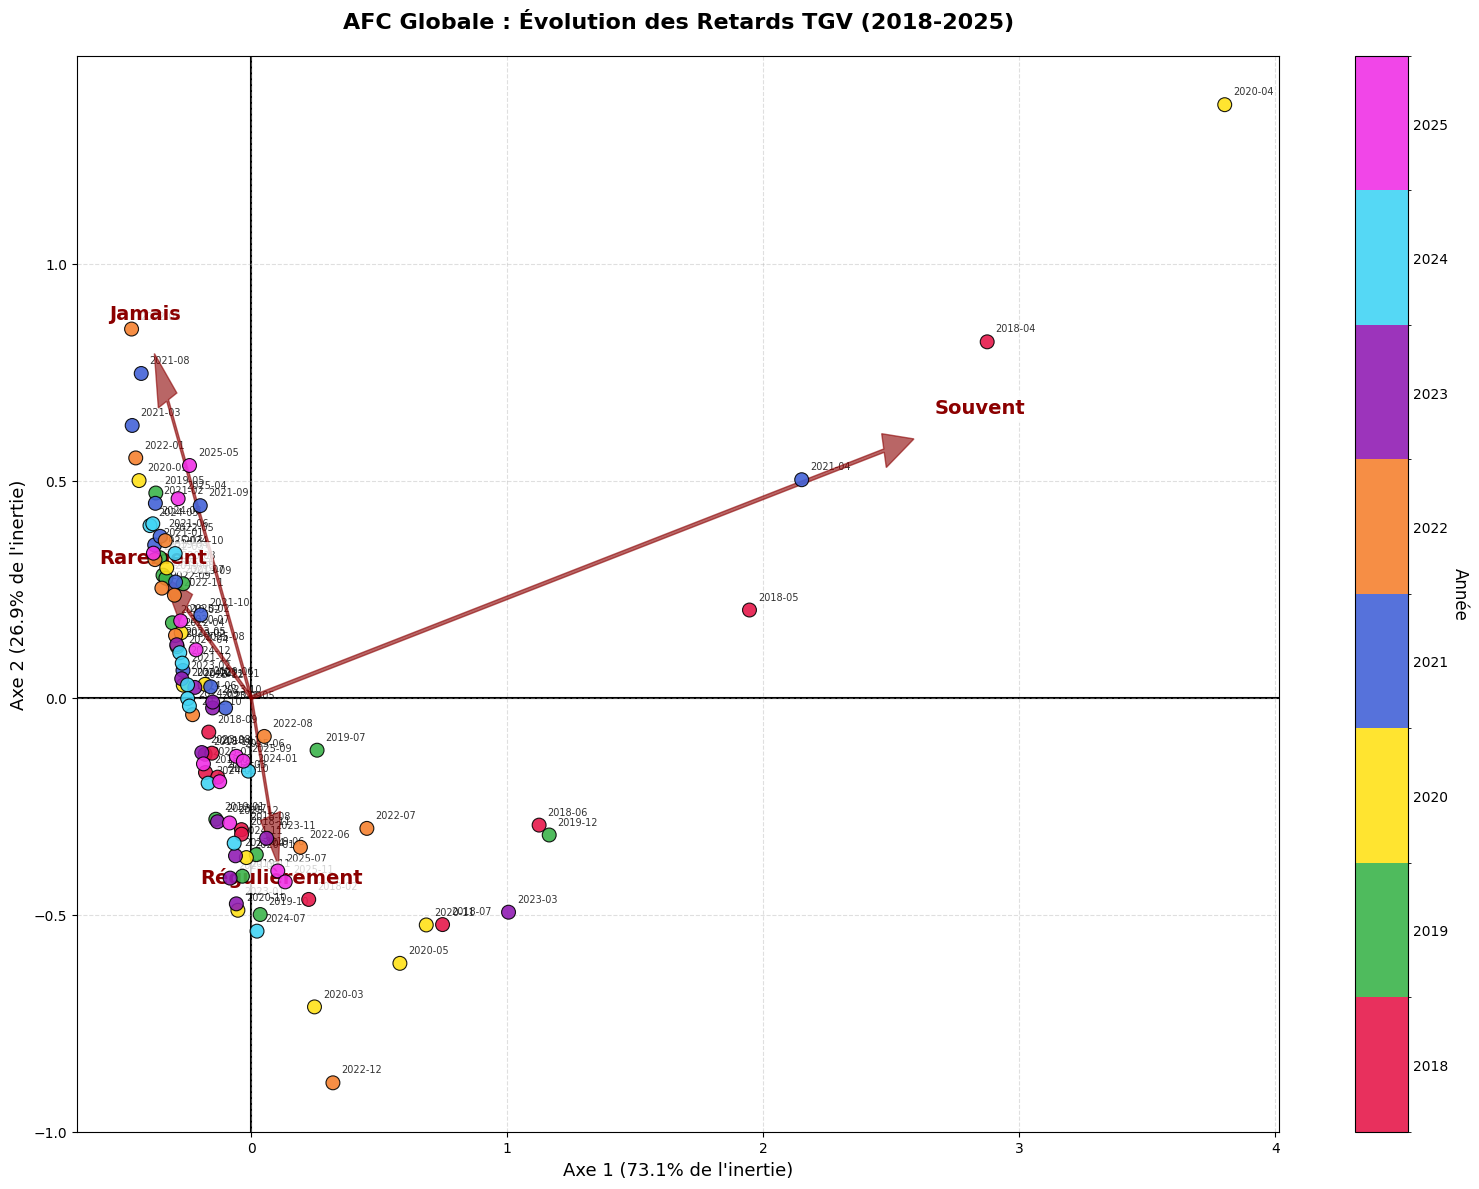

In [26]:
# 1. PRÉPARATION DES DONNÉES

# Créer la période
data['periode'] = data['date'].astype(str)

# Matrice de contingence
matrice_contingence = data.groupby(['periode', 'retard']).size().unstack(fill_value=0)

# Vérification : s'assurer qu'il n'y a pas de lignes vides
if matrice_contingence.empty:
    raise ValueError("La matrice de contingence est vide. Vérifiez vos colonnes 'date' et 'retard'.")

print("Aperçu de la matrice de contingence :")
print(matrice_contingence.head())

# 2. LANCEMENT DE L'AFC
afc = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc = afc.fit(matrice_contingence)

# 3. PRÉPARATION DES COORDONNÉES
coords_individus = afc.row_coordinates(matrice_contingence)
coords_individus.columns = ['Axe 1', 'Axe 2']

# On convertit l'index en Series pour pouvoir utiliser les méthodes de chaîne
index_series = coords_individus.index.to_series()

# Extraction de l'année depuis l'index (ex: "2020-04" -> "2020")
index_series = coords_individus.index.to_series()
coords_individus['annee_str'] = index_series.str[:4]
coords_individus['annee_num'] = coords_individus['annee_str'].astype(int)

# Définition de 8 couleurs bien distinctes et vives
couleurs_personnalisees = [
    '#E6194B', # 2018 : Rouge
    '#3CB44B', # 2019 : Vert
    '#FFE119', # 2020 : Jaune
    '#4363D8', # 2021 : Bleu
    '#F58231', # 2022 : Orange
    '#911EB4', # 2023 : Violet
    '#42D4F4', # 2024 : Cyan
    '#F032E6'  # 2025 : Magenta
]

# Création d'une carte de couleurs personnalisée à partir de la liste
cmap_personnalisee = mcolors.LinearSegmentedColormap.from_list('ma_cmap', couleurs_personnalisees, N=8)

# Création des bornes pour que chaque année ait sa propre case centrée
# Les bornes sont placées "entre" les années : [2017.5, 2018.5, 2019.5, ..., 2025.5]
bornes = [x - 0.5 for x in annees_uniques] + [annees_uniques[-1] + 0.5]
norm = mcolors.BoundaryNorm(bornes, cmap_personnalisee.N)


# --- 4. VISUALISATION AVEC BARRE DE COULEUR "EN CASES" ---
plt.figure(figsize=(16, 12))

# Tracé des variables (Flèches)
for i, txt in enumerate(coords_variables.index):
    x, y = coords_variables['Axe 1'].iloc[i], coords_variables['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True, zorder=5)
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'), zorder=6)

# Tracé des individus avec la nouvelle normalisation
scatter = plt.scatter(
    coords_individus['Axe 1'], 
    coords_individus['Axe 2'], 
    c=coords_individus['annee_num'], 
    cmap=cmap_personnalisee, 
    norm=norm,  # Application de la normalisation discrète
    s=100, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=0.8,
    zorder=10
)

# Annotation des points
for i, txt in enumerate(coords_individus.index):
    x_val = coords_individus['Axe 1'].iloc[i]
    y_val = coords_individus['Axe 2'].iloc[i]
    plt.annotate(txt, (x_val, y_val), 
                 xytext=(6, 6), textcoords='offset points', 
                 fontsize=7, alpha=0.8, ha='left', va='bottom')

# Configuration de la barre de couleur
cbar = plt.colorbar(scatter, ticks=annees_uniques) # Les ticks sont exactement les années
cbar.set_label('Année', rotation=270, labelpad=15, fontsize=12)
cbar.set_ticklabels([str(int(a)) for a in annees_uniques])

# Ajustement des ticks pour qu'ils soient au centre des cases
cbar.ax.tick_params(length=0) # Optionnel : retirer les traits de ticks pour un look plus "case"

plt.title("AFC Globale : Évolution des Retards TGV (2018-2025)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, color='black', linewidth=1.5, zorder=1)
plt.axvline(0, color='black', linewidth=1.5, zorder=1)
plt.grid(True, linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

TODO INTERPRETER LE PREMIER ET INTRODUIRE LE DEUXIÈME

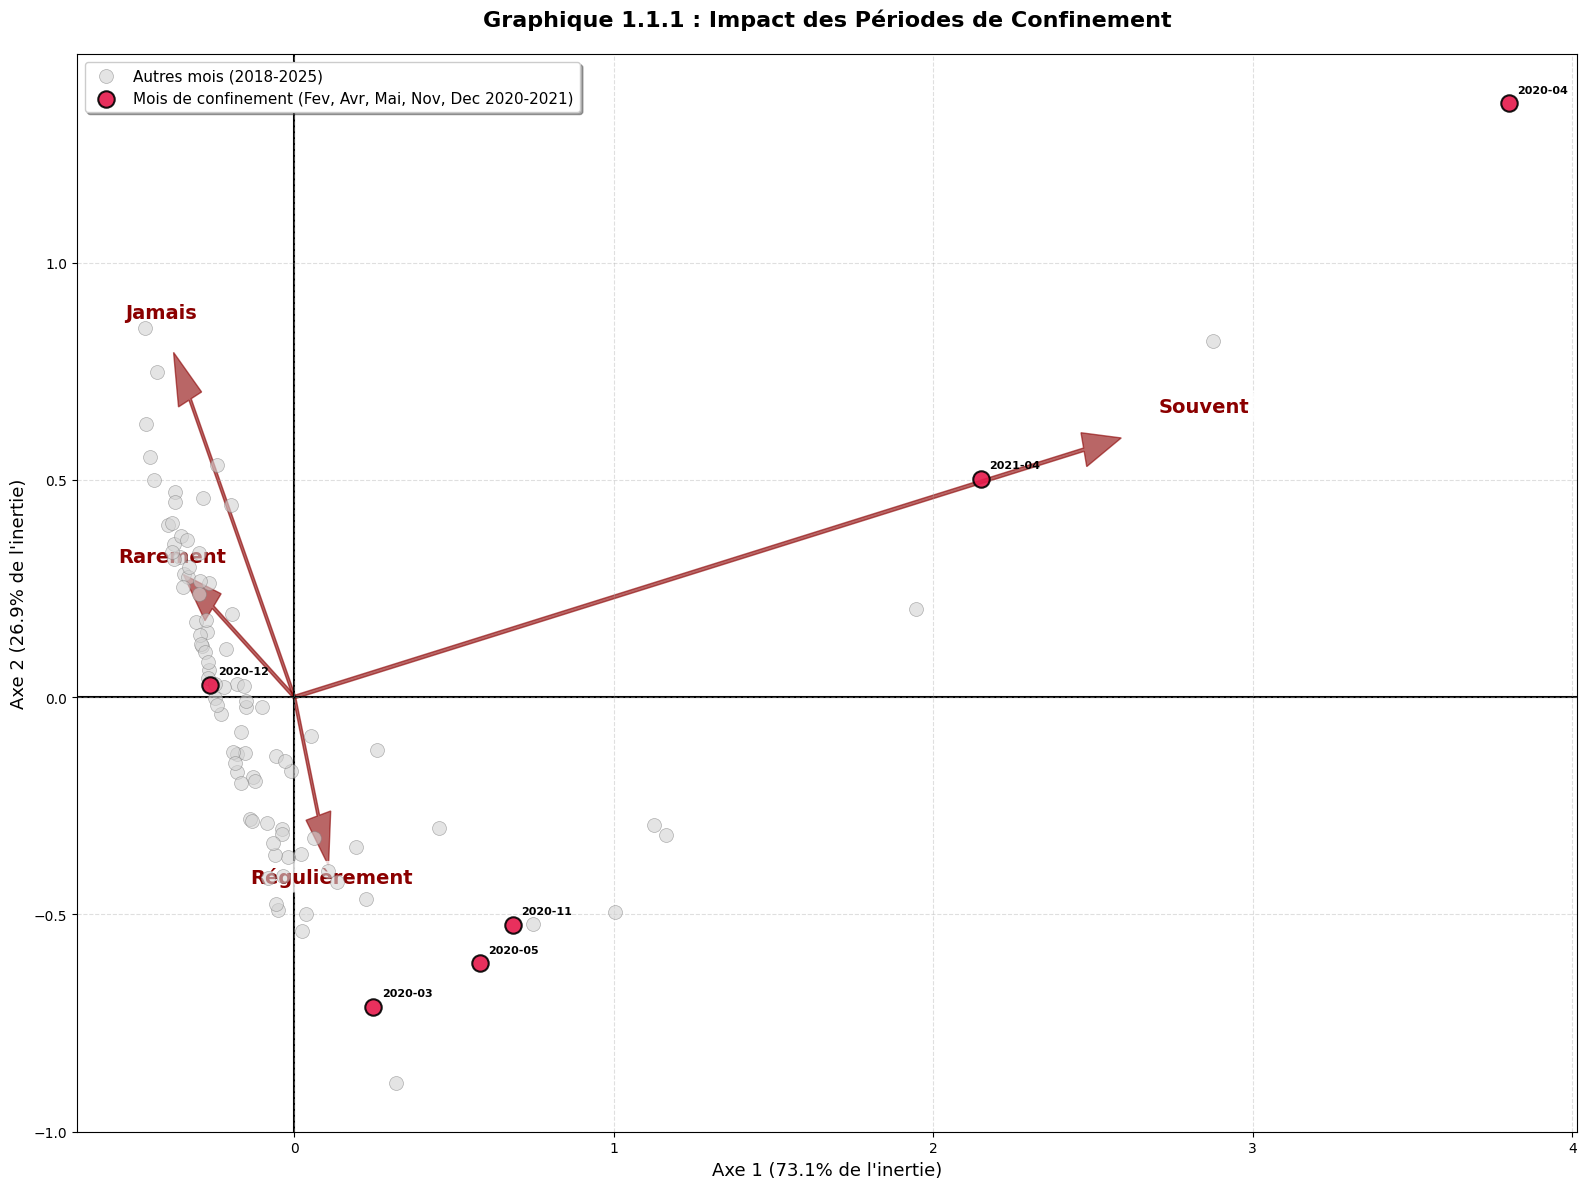

In [ ]:
#Visualisation ciblée : Périodes de confinement

# A. Préparation des données temporelles
coords_individus['mois_num'] = coords_individus.index.str.split('-').str[1].astype(int)

# Définition stricte des périodes de confinement
# Mars(3), Avril(4), Mai(5), Nov(11), Dec(12) en 2020 ET Avril(4) en 2021
liste_periodes = [
    (2020, 3), (2020, 4), (2020, 5), (2020, 11), (2020, 12),
    (2021, 4)
]

# Création d'une condition combinée pour identifier ces périodes spécifiques
# On crée un tuple (année, mois) pour chaque ligne et on vérifie s'il est dans la liste
coords_individus['tuple_date'] = list(zip(coords_individus['annee_num'], coords_individus['mois_num']))
mask_confinement = coords_individus['tuple_date'].isin(liste_periodes)

# Séparation des données pour le tracé
df_confinement = coords_individus[mask_confinement]
df_autres = coords_individus[~mask_confinement]

# B. Visualisation
plt.figure(figsize=(16, 12))

# Tracé des variables (Flèches) - Réutilisation des coordonnées existantes
for i, txt in enumerate(coords_variables.index):
    x, y = coords_variables['Axe 1'].iloc[i], coords_variables['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True, zorder=1)
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'), zorder=2)

# Tracé des individus "Autres" (Gris)
plt.scatter(
    df_autres['Axe 1'], 
    df_autres['Axe 2'], 
    c='lightgray', 
    s=100, 
    alpha=0.6, 
    edgecolors='gray', 
    linewidth=0.5,
    label='Autres mois (2018-2025)',
    zorder=10
)

# Tracé des individus "Confinement" (Rouge)
plt.scatter(
    df_confinement['Axe 1'], 
    df_confinement['Axe 2'], 
    c='#E6194B', 
    s=140, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=1.5,
    label='Mois de confinement (Fev, Avr, Mai, Nov, Dec 2020-2021)',
    zorder=11
)

# Annotation spécifique aux points de confinement
for i, txt in enumerate(df_confinement.index):
    x_val = df_confinement['Axe 1'].iloc[i]
    y_val = df_confinement['Axe 2'].iloc[i]
    plt.annotate(txt, (x_val, y_val), 
                 xytext=(6, 6), textcoords='offset points', 
                 fontsize=8, fontweight='bold', color='black',
                 ha='left', va='bottom', zorder=12)

# Légende et mise en forme
plt.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=11)
plt.title("Graphique 1.1.1 : Impact des Périodes de Confinement", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, color='black', linewidth=1.5, zorder=1)
plt.axvline(0, color='black', linewidth=1.5, zorder=1)
plt.grid(True, linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

On peut identifier une tendance supplémentaire des mois de confinements pour les retards et annulations de train. Ce qui semble plutôt cohérent. Nous referons des analyses en sortant ces mois-ci ainsi que les mois du printemps 2018 qui ont été secoué par des trop grosses grèves des cheminots. Nous verrons à quel point les axes des variables sont influencés par ces outliers.

Nous refaisons maintenant une nouvelle AFC sur les données agrégées de chaque année pour voir les tendances lourdes pouvant se dégager. Il ne s'agit pas d'une 

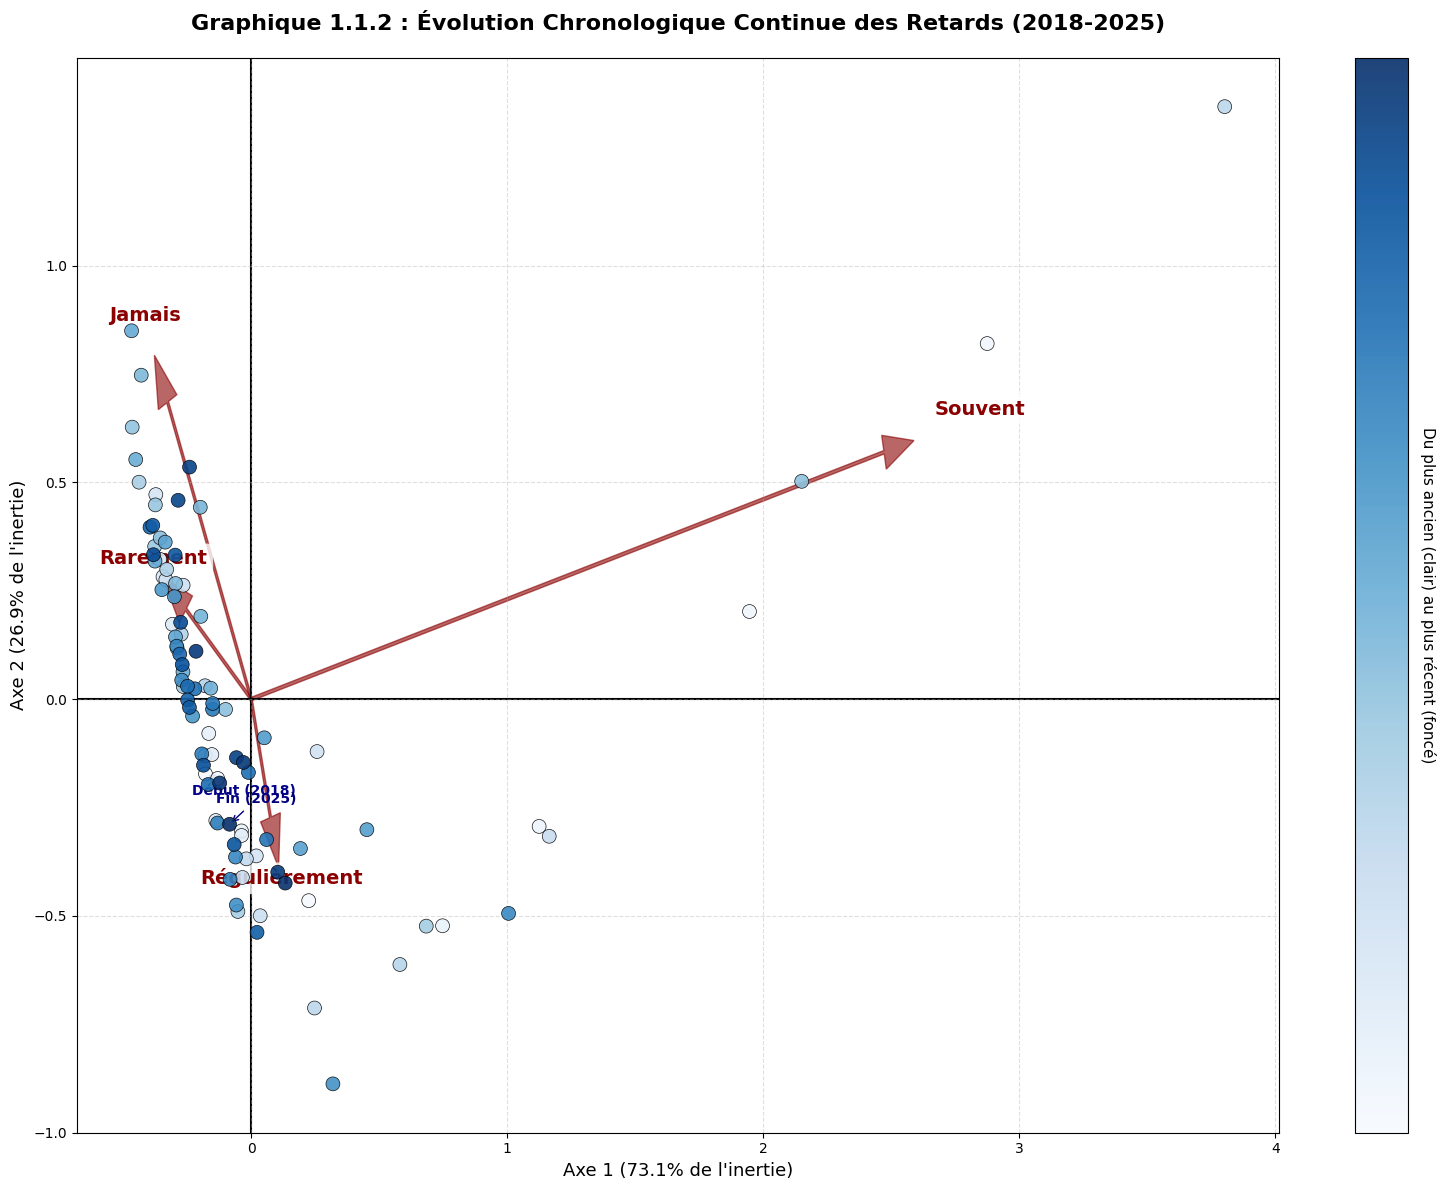

In [36]:
# 1.1.2. Visualisation de la tendance temporelle continue (Time Gradient)

# A. Création d'un index temporel continu
# On convertit l'index (ex: "2018-01") en objet datetime pour le trier chronologiquement
coords_individus['date_obj'] = pd.to_datetime(coords_individus.index)
coords_individus = coords_individus.sort_values('date_obj')

# On crée un index numérique continu (0 à N) représentant l'écoulement du temps
# 0 = Janvier 2018, 1 = Février 2018, ..., 95 = Décembre 2025
coords_individus['time_index'] = np.arange(len(coords_individus))

# B. Visualisation
plt.figure(figsize=(16, 12))

# Tracé des variables (Flèches) - Inchangé
for i, txt in enumerate(coords_variables.index):
    x, y = coords_variables['Axe 1'].iloc[i], coords_variables['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True, zorder=1)
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'), zorder=2)

# Tracé des individus avec dégradé de couleur
# On utilise 'time_index' comme valeur de couleur pour créer le gradient
scatter = plt.scatter(
    coords_individus['Axe 1'], 
    coords_individus['Axe 2'], 
    c=coords_individus['time_index'], 
    cmap='Blues',  # Palette monotone : du bleu clair au bleu foncé
    s=100, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=0.5,
    zorder=10
)

# Annotation légère (optionnel, peut être retiré si trop chargé)
# On annote seulement le premier et le dernier point pour montrer le sens du temps
first_point = coords_individus.iloc[0]
last_point = coords_individus.iloc[-1]

plt.annotate("Début (2018)", (first_point['Axe 1'], first_point['Axe 2']), 
             xytext=(-10, -15), textcoords='offset points', fontsize=10, color='darkblue', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='darkblue'))

plt.annotate("Fin (2025)", (last_point['Axe 1'], last_point['Axe 2']), 
             xytext=(-10, 15), textcoords='offset points', fontsize=10, color='navy', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='navy'))

# Configuration de la barre de couleur (Gradient continu)
cbar = plt.colorbar(scatter, label='Écoulement du temps (Chronologie)')
cbar.set_ticks([]) # On retire les ticks numériques pour garder un aspect pur "dégradé"
cbar.ax.set_ylabel('Du plus ancien (clair) au plus récent (foncé)', rotation=270, labelpad=20, fontsize=11)

plt.title("Graphique 1.1.2 : Évolution Chronologique Continue des Retards (2018-2025)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, color='black', linewidth=1.5, zorder=1)
plt.axvline(0, color='black', linewidth=1.5, zorder=1)
plt.grid(True, linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.show()

# Nettoyage des colonnes temporaires
coords_individus.drop(columns=['date_obj', 'time_index'], inplace=True)


Matrice de contingence Annuelle (8 individus) :
retard     Jamais  Rarement  Régulièrement  Souvent
annee_str                                          
2018           25       434            889      212
2019           39       697            689       51
2020           10       588            698      107
2021           83       851            439       76
2022           64       757            612       34
2023           13       606            792       35
2024           36       772            639        8
2025           34       756            685       30


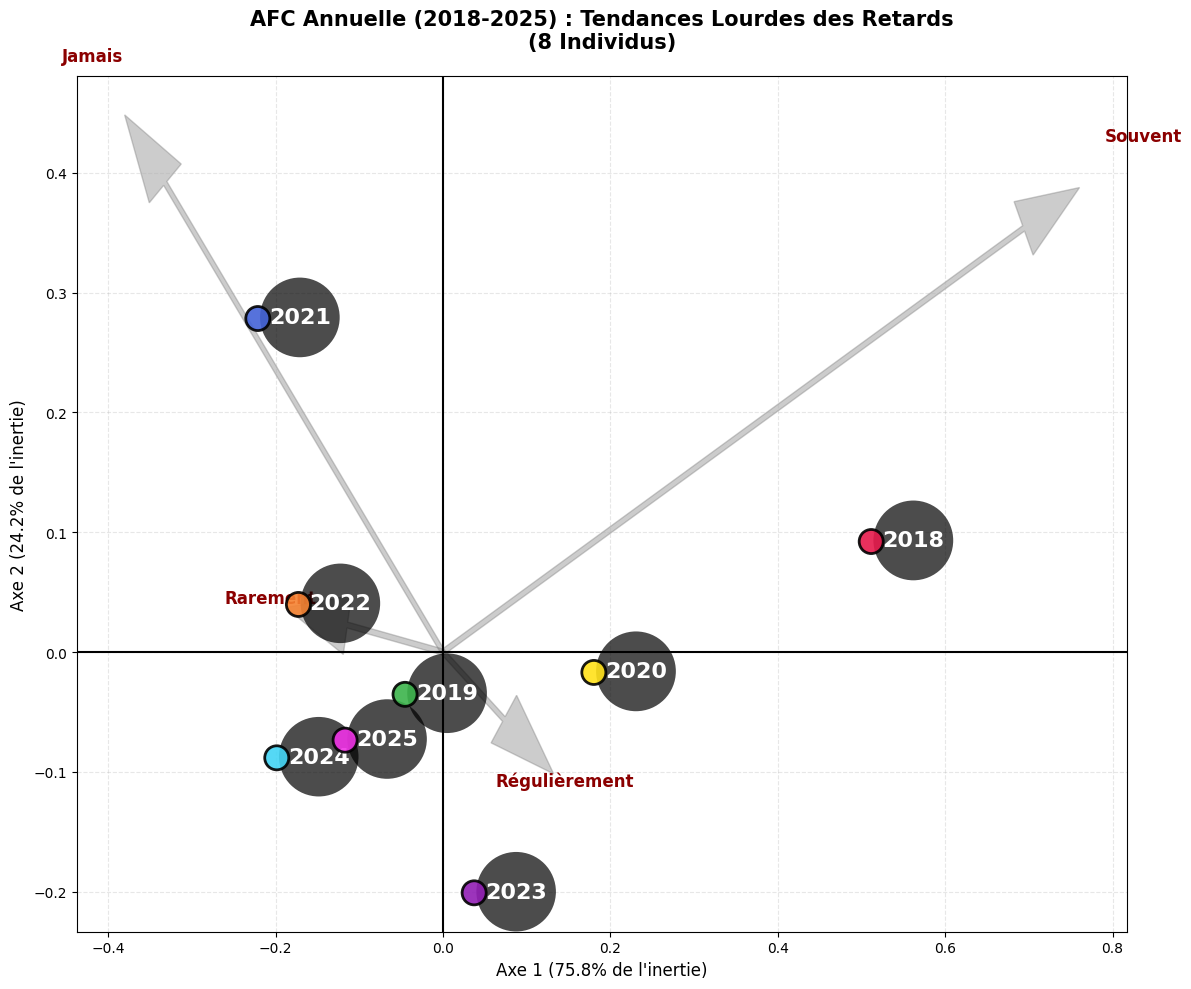

In [35]:
#6. AFC SPÉCIFIQUE PAR ANNÉE (8 Individus)

# A. Création de la colonne 'annee' extraite de la date
# On prend les 4 premiers caractères pour être sûr d'avoir l'année.
data['annee_str'] = data['date'].astype(str).str[:4]

# B. Création de la matrice de contingence par ANNÉE
# Groupby (Année, Retard) -> Comptage -> Pivot (unstack)
matrice_annuelle = data.groupby(['annee_str', 'retard']).size().unstack(fill_value=0)

print("\nMatrice de contingence Annuelle (8 individus) :")
print(matrice_annuelle)

# C. Lancement de l'AFC sur les données annuelles
afc_annee = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_annee = afc_annee.fit(matrice_annuelle)

# D. Calcul des inerties pour les titres
total_inertia_annee = afc_annee.eigenvalues_.sum()
inertie_a1 = afc_annee.eigenvalues_[0] / total_inertia_annee
inertie_a2 = afc_annee.eigenvalues_[1] / total_inertia_annee

# E. Visualisation
plt.figure(figsize=(12, 10))

# Récupérer les coordonnées des individus (les années)
coords_annees = afc_annee.row_coordinates(matrice_annuelle)
coords_annees.columns = ['Axe 1', 'Axe 2']

# Récupérer les coordonnées des variables (les catégories de retard) pour les superposer
coords_vars_annee = afc_annee.column_coordinates(matrice_annuelle)
coords_vars_annee.columns = ['Axe 1', 'Axe 2']

# 1. Tracer les flèches des variables (Catégories) en fond
for i, txt in enumerate(coords_vars_annee.index):
    x = coords_vars_annee['Axe 1'].iloc[i]
    y = coords_vars_annee['Axe 2'].iloc[i]
    # Flèche depuis l'origine
    plt.arrow(0, 0, x, y, color='gray', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True)
    # Nom de la catégorie au bout de la flèche
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=12, fontweight='bold', ha='center')

# 2. Tracer les points des ANNÉES par dessus
# On utilise l'index (qui est l'année) converti en entier pour la couleur
coords_annees['annee_num'] = coords_annees.index.astype(int)

scatter_annee = plt.scatter(
    coords_annees['Axe 1'], 
    coords_annees['Axe 2'], 
    c=coords_annees['annee_num'], 
    cmap=cmap_personnalisee, 
    s=300, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10,
    label='Années'
)

# Ajouter le label de l'année à côté du point
for i, txt in enumerate(coords_annees.index):
    x_val = coords_annees['Axe 1'].iloc[i]
    y_val = coords_annees['Axe 2'].iloc[i]
    # Texte blanc avec contour noir pour lisibilité maximale
    plt.annotate(f"{txt}", (x_val, y_val), 
                 xytext=(8, 8),          # Décalage de 8 points vers le haut-droite
                 textcoords='offset points', # L'unité est en points d'impression (indépendant de l'échelle du graph)
                 ha='left',              # Alignement horizontal à gauche du texte décalé
                 va='top',            # Alignement vertical en bas du texte décalé
                 fontsize=16,            
                 fontweight='bold', 
                 color='white',
                 bbox=dict(boxstyle='circle,pad=0.4', facecolor='black', alpha=0.7, edgecolor='none'))


plt.title("AFC Annuelle (2018-2025) : Tendances Lourdes des Retards\n(8 Individus)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_a1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_a2:.1%} de l'inertie)", fontsize=12)

# Grille et axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

On observe une répartition des individus (vu en tant que un mois d'une année) sur les deux axes avec une forme de "banane" particulière. On n'observe pas de périodes particulièrement concentrées quelque part :

On voit que les années 2018 et 2020 sont clairement plus touchées par les retards et qu'il sera intéressant de revoir l'AFC sans les mois "outliers". L'année 2021 est dans la direction de la variable `Jamais`. Elle peut être considérée comme une année performante par rapport aux 8 dernières.

On ne voit pas de tendances globales sur l'ensemble des années qui pourrait nous faire estimer que les retards diminuent ou baissent. On retrouve la vision que les retards moyens semblent se lisser récemment pour stagner entre rarement et régulièrement.

On regarde maintenant les effets saisonniers et l'évolution des retards par mois. Nous refaisons une nouvelle AFC sur les données agrégées en mois. Nous cherchons à savoir si il y a des mois plus propices aux retards que d'autres.

Matrice de contingence
retard    Jamais  Rarement  Régulièrement  Souvent
mois_num                                          
01            15       483            477        6
02            50       542            380        9
03            27       487            436       31
04            28       365            322      218
05            33       491            371       81
06            19       384            528       47
07            12       354            578       53
08            50       559            375       12
09            26       589            366       14
10            16       466            487       10
11            17       348            585       33
12            11       393            538       39


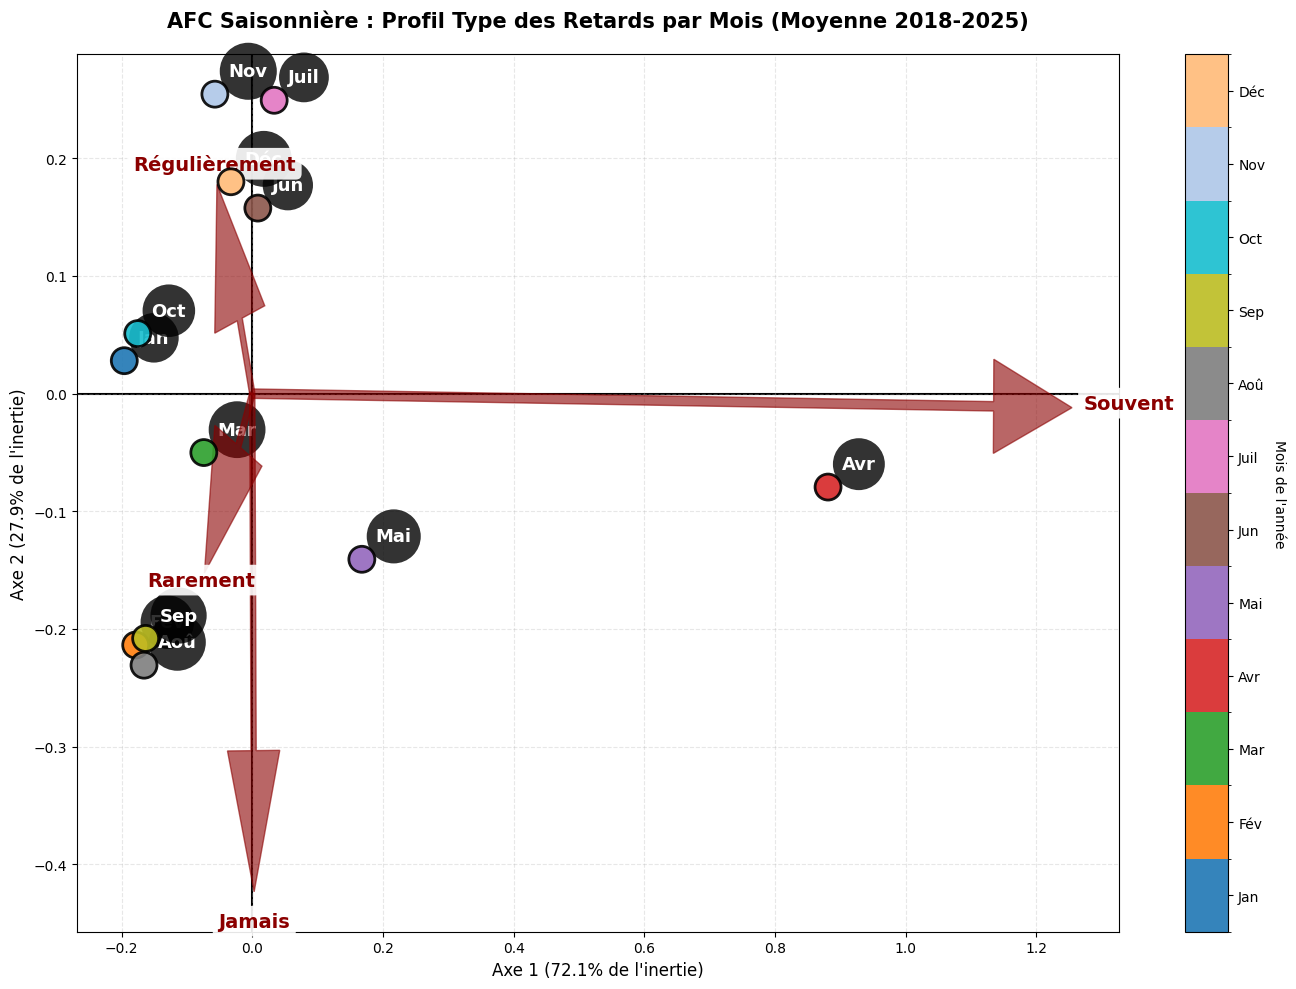

In [ ]:
# 1.3. AFC Saisonnière Globale (12 Mois)

# A. Préparation : Extraire le numéro du mois pour le regroupement
data['mois_num'] = data['date'].astype(str).str.split('-').str[1]

# B. Création de la matrice de contingence par MOIS (Agrégation 2018-2025)
matrice_mois = data.groupby(['mois_num', 'retard']).size().unstack(fill_value=0)

# Réordonner les mois chronologiquement (01, 02, ..., 12)
ordre_mois = [f"{i:02d}" for i in range(1, 13)]
mois_presents = [m for m in ordre_mois if m in matrice_mois.index]
matrice_mois = matrice_mois.reindex(mois_presents)

#Afficher la matrice de contigence
print("Matrice de contingence")
print(matrice_mois)

# C. Lancement de l'AFC
afc_mois_global = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_mois_global = afc_mois_global.fit(matrice_mois)

# D. Calcul des inerties
total_inertia_mois = afc_mois_global.eigenvalues_.sum()
inertie_mm1 = afc_mois_global.eigenvalues_[0] / total_inertia_mois
inertie_mm2 = afc_mois_global.eigenvalues_[1] / total_inertia_mois

# E. Préparation des coordonnées
coords_mois_glob = afc_mois_global.row_coordinates(matrice_mois)
coords_mois_glob.columns = ['Axe 1', 'Axe 2']
coords_mois_glob['mois_int'] = coords_mois_glob.index.astype(int)

coords_vars_mois = afc_mois_global.column_coordinates(matrice_mois)
coords_vars_mois.columns = ['Axe 1', 'Axe 2']

# F. Création d'une palette personnalisée de 12 couleurs distinctes
# Liste de 12 couleurs vives et différenciables
couleurs_12_mois = [
    '#1f77b4', # Bleu (Jan)
    '#ff7f0e', # Orange (Fév)
    '#2ca02c', # Vert (Mar)
    '#d62728', # Rouge (Avr)
    '#9467bd', # Violet (Mai)
    '#8c564b', # Marron (Jun)
    '#e377c2', # Rose (Juil)
    '#7f7f7f', # Gris (Aoû)
    '#bcbd22', # Olive (Sep)
    '#17becf', # Cyan (Oct)
    '#aec7e8', # Bleu clair (Nov)
    '#ffbb78'  # Orange clair (Déc)
]

# Création de la colormap et de la normalisation pour des cases discrètes (pour avoir les couleurs centrées sur les mois)
cmap_12 = mcolors.LinearSegmentedColormap.from_list('cmap_12', couleurs_12_mois, N=12)
bornes_mois = [x - 0.5 for x in range(1, 13)] + [12.5] # Bornes de 0.5 à 12.5
norm_mois = mcolors.BoundaryNorm(bornes_mois, cmap_12.N)

# G. Visualisation Unifiée
plt.figure(figsize=(14, 10))

# 1. Tracé des VARIABLES (Flèches)
for i, txt in enumerate(coords_vars_mois.index):
    x = coords_vars_mois['Axe 1'].iloc[i]
    y = coords_vars_mois['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True, zorder=5)
    plt.text(x*1.07, y*1.07, txt, 
             color='darkred', fontsize=14, fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='none'), zorder=6)

# 2. Tracé des INDIVIDUS (Les Mois 01-12) avec la nouvelle palette
scatter_mois_glob = plt.scatter(
    coords_mois_glob['Axe 1'], 
    coords_mois_glob['Axe 2'], 
    c=coords_mois_glob['mois_int'], 
    cmap=cmap_12, 
    norm=norm_mois, # Application de la normalisation discrète
    s=350, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10
)

# 3. Annotation des points (Nom du mois)
noms_mois = {
    '01': 'Jan', '02': 'Fév', '03': 'Mar', '04': 'Avr', '05': 'Mai', '06': 'Jun',
    '07': 'Juil', '08': 'Aoû', '09': 'Sep', '10': 'Oct', '11': 'Nov', '12': 'Déc'
}

for i, txt in enumerate(coords_mois_glob.index):
    label = noms_mois.get(txt, txt)
    x_val = coords_mois_glob['Axe 1'].iloc[i]
    y_val = coords_mois_glob['Axe 2'].iloc[i]
    
    plt.annotate(label, (x_val, y_val), 
                 xytext=(10, 10), textcoords='offset points', 
                 ha='left', va='bottom', fontsize=13, fontweight='bold', color='white',
                 bbox=dict(boxstyle='circle,pad=0.5', facecolor='black', alpha=0.8, edgecolor='none'))

# H. Mise en forme et Légende
plt.title("AFC Saisonnière : Profil Type des Retards par Mois (Moyenne 2018-2025)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_mm1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_mm2:.1%} de l'inertie)", fontsize=12)

plt.axhline(0, color='black', linewidth=1.5, zorder=1)
plt.axvline(0, color='black', linewidth=1.5, zorder=1)
plt.grid(True, linestyle='--', alpha=0.3, zorder=0)

# Légende de couleur avec cases discrètes
cbar = plt.colorbar(scatter_mois_glob, ticks=range(1, 13))
cbar.set_label('Mois de l\'année', rotation=270, labelpad=15)
cbar.set_ticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])

plt.tight_layout()
plt.show()

On voit que Avril reste un outlier car très fortement impacté par les annés 2018, 2020 et 2021 dans nos données.

Le mois de mai a un comportement plutôt étonnant car il comporte beaucoup de `Rarement en retard` et de `Souvent en retard`, ce qui le sort de la forme générale (allant d'en bas à gauche à en haut à droite en passant par en haut à gauche) qui classe globalement les mois par performance de ponctualité.

Août, Septembre et Février présente un profil très similaire et performant. Ces mois répondent à notre question initiale des meilleurs moments pour prendre le train.

Viennent ensuite Janvier, Octobre et Mars avec plus de retard et enfin Juin, Juillet, Novembre et Décembre qui sont très proches de la position de la variable `Régulièrement en retard`.

On peut voir un effet des vacances d'été et de Noël sur les retards avec Juin, Juillet et Décembre dans les mois les moins performants. Août se positionne mieux cependant.

k-means / cluster autre methodes

## FAMD avec la proportion de retard

Nous allons maintenant prendre uniquement la variable `Retard` qui est continue et l'utiliser pour coupler les deux AFC dans une AFCM. Il s'agit d'un cas très adapté pour cette méthode car nos données sont temporelles et nous voulons à la fois chercher les effets des années et des mois sur les données et le retard.

On repart des données initiales pour créer un data set spécial pour la FAMD.

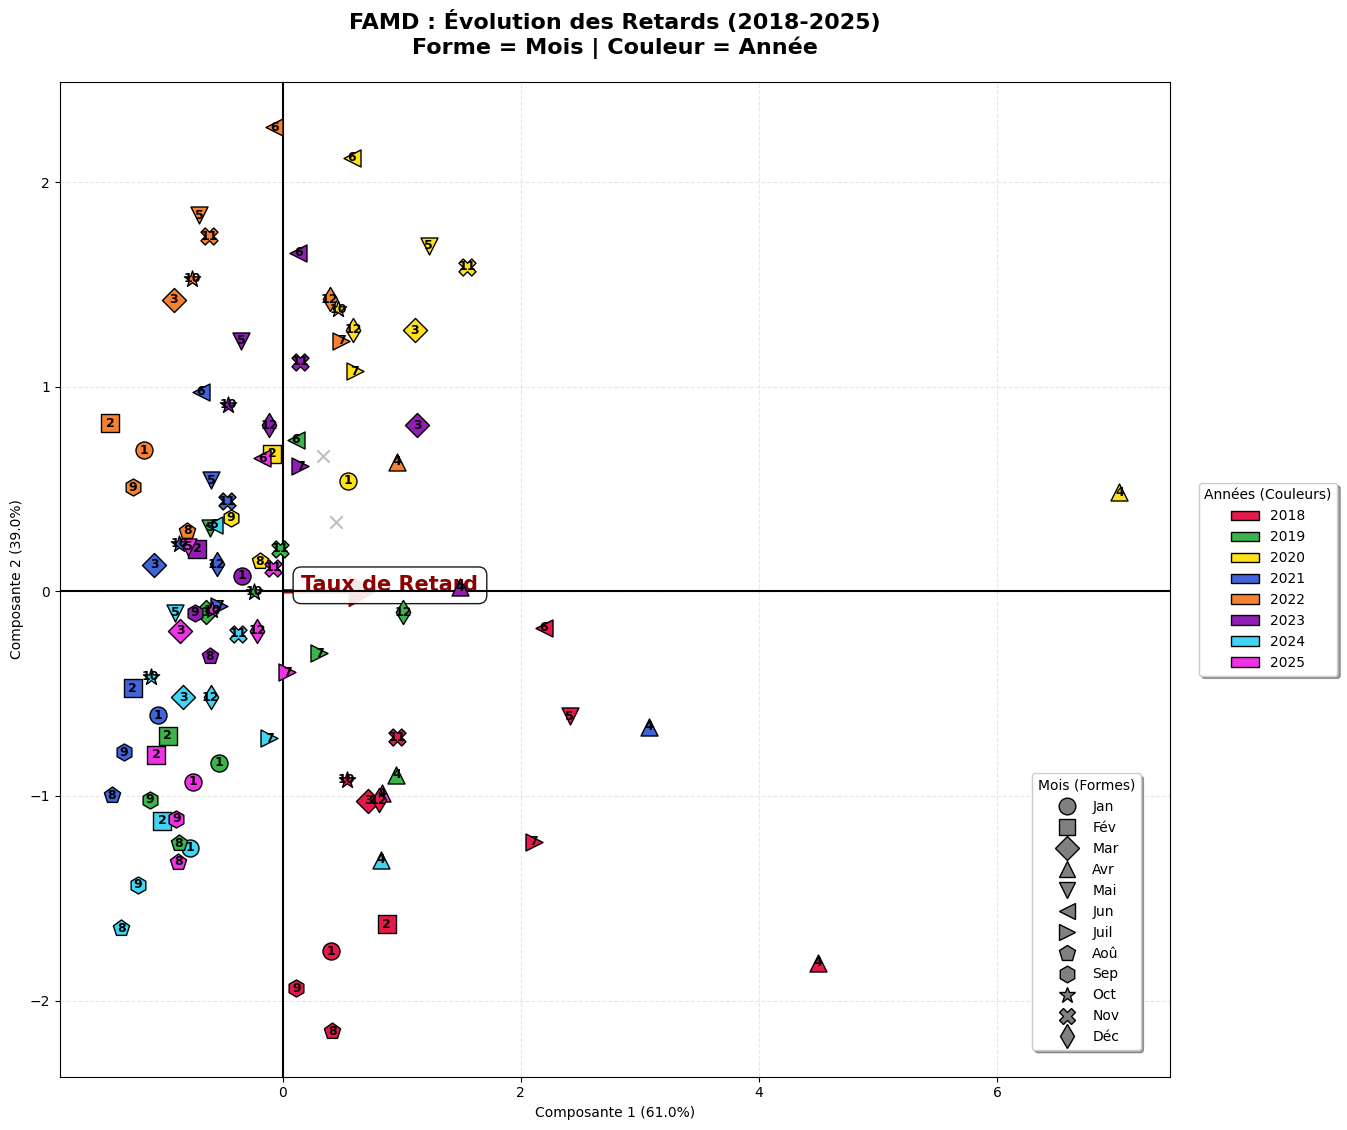

In [64]:
# 2.1. FAMD : Variable quantitative continue (Taux de retard)

# A. Préparation des données
df_famd = data.copy()

# Création des variables temporelles
df_famd['date_str'] = df_famd['date'].astype(str)
df_famd['annee_var'] = df_famd['date_str'].str[:4].astype('object')
df_famd['mois_var'] = df_famd['date_str'].str.split('-').str[1].astype('object')
df_famd['individu'] = df_famd['mois_var'] + '-' + df_famd['annee_var']

# Agrégation par individu (Mois-Année)
agg_data = df_famd.groupby(['individu', 'mois_var', 'annee_var']).agg({
    'arr_late_trains': 'sum',
    'cancelled_trains': 'sum',
    'planned_trains': 'sum'
}).reset_index()

# Calcul de la variable quantitative : Proportion de retard (Valeur continue)
agg_data['proportion_retard'] = (
    agg_data['arr_late_trains'] + agg_data['cancelled_trains']
) / agg_data['planned_trains']

# Préparation du dataframe final
df_final = agg_data[['individu', 'mois_var', 'annee_var', 'proportion_retard']].copy()
df_final.set_index('individu', inplace=True)

# B. Lancement de la FAMD
famd = prince.FAMD(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
famd = famd.fit(df_final)

# C. Récupération des coordonnées
coords_ind = famd.row_coordinates(df_final).copy()
coords_ind.columns = ['Axe 1', 'Axe 2']

coords_var = famd.column_coordinates_.copy()
coords_var.columns = ['Axe 1', 'Axe 2']

# Extraction des infos pour le graphique (Correction : ajout de annee_str)
coords_ind['annee_num'] = coords_ind.index.str.split('-').str[1].astype(int)
coords_ind['annee_str'] = coords_ind.index.str.split('-').str[1]  # Colonne manquante ajoutée
coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)

# Séparation des variables pour le tracé
if 'proportion_retard' in coords_var.index:
    var_quant = coords_var.loc[['proportion_retard']]
    var_qual = coords_var.drop('proportion_retard')
else:
    var_quant = coords_var.iloc[[0]]
    var_qual = coords_var.iloc[1:]

# D. Visualisation
plt.figure(figsize=(16, 12))

# 1. Définition des styles
# Couleurs vives par année
couleurs_vives_annees = [
    '#E6194B', '#3CB44B', '#FFE119', '#4363D8', 
    '#F58231', '#911EB4', '#42D4F4', '#F032E6'
]
annees_uniques = sorted(coords_ind['annee_str'].unique())
dict_couleurs_annees = {annee: couleurs_vives_annees[i % len(couleurs_vives_annees)] for i, annee in enumerate(annees_uniques)}

# Formes par mois
liste_marqueurs_mois = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*', 'X', 'd']
mois_uniques = sorted(coords_ind['mois_num'].unique())
dict_marqueurs_mois = {mois: liste_marqueurs_mois[(mois-1) % len(liste_marqueurs_mois)] for mois in mois_uniques}

noms_mois = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Jun', 
             7: 'Juil', 8: 'Aoû', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'}

# 2. Tracé des variables (Fond)
# Flèche Variable Quantitative
x_q, y_q = var_quant['Axe 1'].iloc[0], var_quant['Axe 2'].iloc[0]
plt.arrow(0, 0, x_q, y_q, color='darkred', alpha=0.9, width=0.015, head_width=0.15, length_includes_head=True, zorder=1)
plt.text(x_q*1.15, y_q*1.15, "Taux de Retard", color='darkred', fontsize=15, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9), zorder=2, ha='center')

# Points Variables Qualitatives
for idx, row in var_qual.iterrows():
    x, y = row['Axe 1'], row['Axe 2']
    plt.scatter(x, y, c='gray', s=80, marker='x', alpha=0.5, zorder=1)

# 3. Tracé des individus (Boucle par MOIS)
for mois in mois_uniques:
    df_mois = coords_ind[coords_ind['mois_num'] == mois]
    marker = dict_marqueurs_mois[mois]
    label_mois = noms_mois[mois]
    
    for i, row in df_mois.iterrows():
        annee = row['annee_str']
        couleur = dict_couleurs_annees[annee]
        
        plt.scatter(row['Axe 1'], row['Axe 2'], 
                    c=couleur, 
                    marker=marker, 
                    s=150, 
                    edgecolors='black', 
                    linewidth=1, 
                    alpha=1.0, 
                    zorder=10,
                    label=label_mois if i == df_mois.index[0] else "")
        
# Annotation du numéro du mois à l'intérieur de chaque symbole
    for i, row in df_mois.iterrows():
        plt.text(row['Axe 1'], row['Axe 2'], str(int(row['mois_num'])), 
                 fontsize=9, ha='center', va='center', fontweight='bold', color='black', zorder=11)

# 4. Légendes
# Légende des Mois (Formes)
handles_mois = [plt.Line2D([0], [0], marker=dict_marqueurs_mois[m], color='w', label=noms_mois[m],
                     markerfacecolor='gray', markersize=12, markeredgecolor='black') for m in range(1, 13)]
leg_mois = plt.legend(handles=handles_mois, title="Mois (Formes)", loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=True, fancybox=True, shadow=True)
plt.gca().add_artist(leg_mois)

# Légende des Années (Couleurs)
handles_annees = [Patch(facecolor=dict_couleurs_annees[a], edgecolor='black', label=a) for a in annees_uniques]
leg_annees = plt.legend(handles=handles_annees, title="Années (Couleurs)", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fancybox=True, shadow=True)

# 5. Titres et Axes
total_inertia = famd.eigenvalues_.sum()
inertie_1 = famd.eigenvalues_[0] / total_inertia
inertie_2 = famd.eigenvalues_[1] / total_inertia

plt.title(f"FAMD : Évolution des Retards (2018-2025)\nForme = Mois | Couleur = Année", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Composante 1 ({inertie_1:.1%})")
plt.ylabel(f"Composante 2 ({inertie_2:.1%})")

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0.05, 0.85, 1])
plt.show()

couleur différentes pour les mois / formes différentes pour les années

rajouter les numéros des mois
enleve avril 2020 pour mieux voir les autres
relier les points par années (petits graphs par années ou dashboard)

## Analyse de l'année 2018

Données filtrées : 1560 lignes pour l'année 2018.

Matrice de contingence Mensuelle 2018 :
retard        Jamais  Rarement  Régulièrement  Souvent
periode_mois                                          
2018-01            1        61             68        0
2018-02            3        26             94        7
2018-03            2        57             70        1
2018-04            2         2             38       88
2018-05            1         3             68       58
2018-06            0         7             91       32
2018-07            0         8            102       20
2018-08            3        45             80        2
2018-09            4        61             64        1
2018-10            5        57             68        0
2018-11            2        46             80        2
2018-12            2        61             66        1


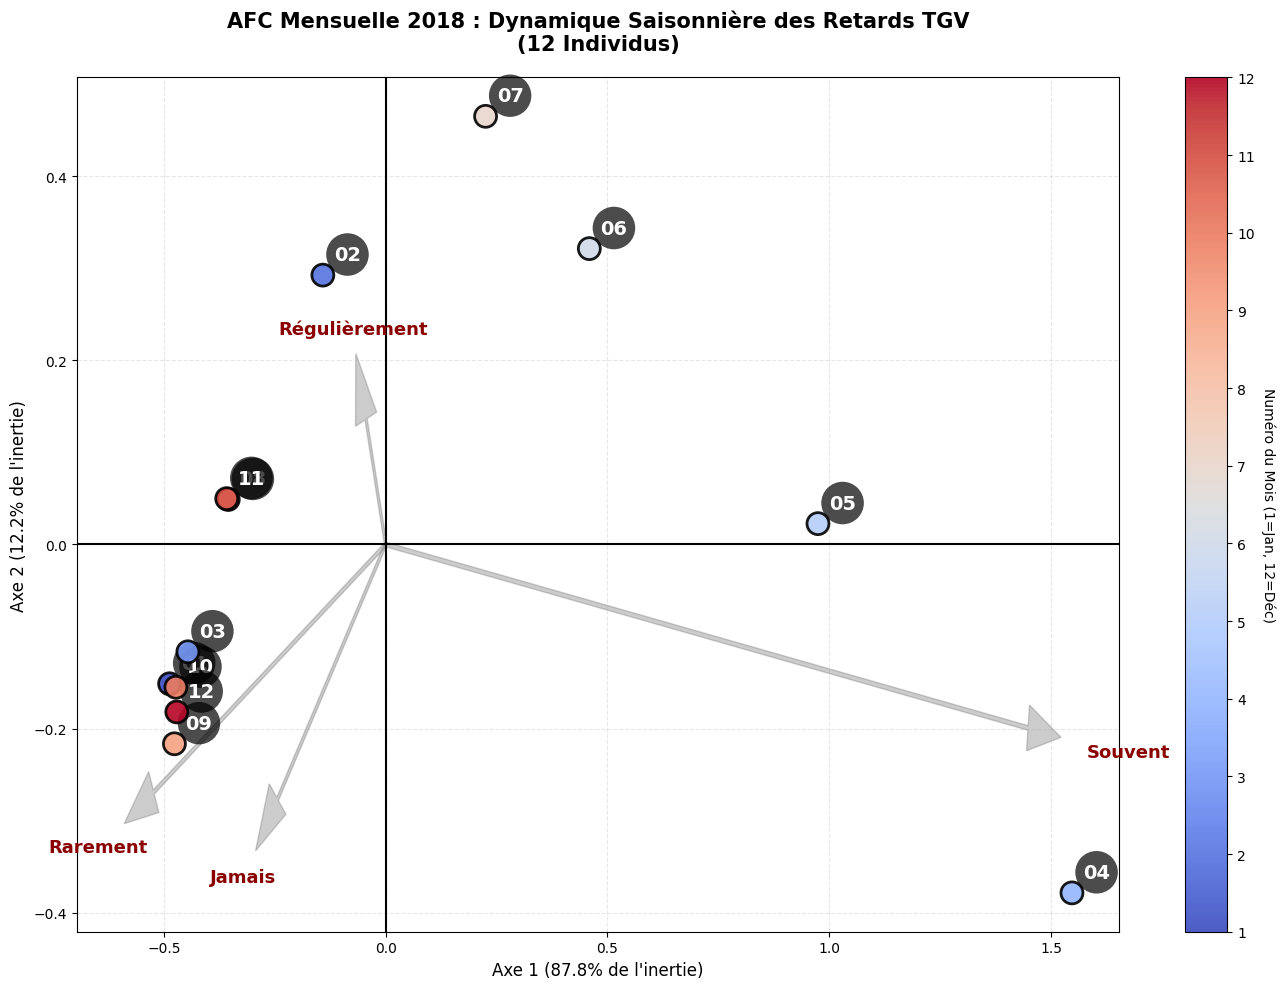


--- Analyse 2018 ---
L'axe 1 explique 87.8% des variations entre les mois de 2018.
L'axe 2 explique 12.2% des variations entre les mois de 2018.
Observez si les mois se suivent chronologiquement (saisonnalité forte) ou s'ils sont dispersés (aléatoire).


In [9]:
#AFC sur année 2018 pour chaque mois (12 individus)
# --- 7. AFC SPÉCIFIQUE POUR L'ANNÉE 2018 (12 Individus : les mois) ---

# A. Filtrage des données pour ne garder que 2018
# On s'assure d'extraire l'année pour filtrer proprement
data['annee_check'] = data['date'].astype(str).str[:4]
data_2018 = data[data['annee_check'] == '2018'].copy()

if data_2018.empty:
    raise ValueError("Aucune donnée trouvée pour l'année 2018. Vérifiez vos dates.")

print(f"Données filtrées : {len(data_2018)} lignes pour l'année 2018.")

# B. Création de la colonne 'mois' pour l'affichage
# Si votre colonne 'date' est "2018-04", on garde tout. 
# Si vous voulez un nom de mois (Avril), il faudrait un mapping, mais gardons le format date pour l'instant.
# Pour l'AFC, l'individu est le mois.
data_2018['periode_mois'] = data_2018['date'].astype(str)

# C. Création de la matrice de contingence par MOIS (pour 2018 uniquement)
matrice_2018 = data_2018.groupby(['periode_mois', 'retard']).size().unstack(fill_value=0)

# Réordonner chronologiquement (si le format est YYYY-MM, le tri alpha fonctionne)
matrice_2018 = matrice_2018.reindex(sorted(matrice_2018.index))

print("\nMatrice de contingence Mensuelle 2018 :")
print(matrice_2018)

# D. Lancement de l'AFC sur les données de 2018
afc_2018 = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_2018 = afc_2018.fit(matrice_2018)

# E. Calcul des inerties
total_inertia_2018 = afc_2018.eigenvalues_.sum()
inertie_m1 = afc_2018.eigenvalues_[0] / total_inertia_2018
inertie_m2 = afc_2018.eigenvalues_[1] / total_inertia_2018

# F. Visualisation
plt.figure(figsize=(14, 10))

# 1. Récupérer les coordonnées des individus (les mois de 2018)
coords_mois = afc_2018.row_coordinates(matrice_2018)
coords_mois.columns = ['Axe 1', 'Axe 2']

# 2. Récupérer les coordonnées des variables (les catégories de retard)
coords_vars_2018 = afc_2018.column_coordinates(matrice_2018)
coords_vars_2018.columns = ['Axe 1', 'Axe 2']

# 3. Tracer les flèches des variables (Catégories) en fond
for i, txt in enumerate(coords_vars_2018.index):
    x = coords_vars_2018['Axe 1'].iloc[i]
    y = coords_vars_2018['Axe 2'].iloc[i]
    # Flèche depuis l'origine
    plt.arrow(0, 0, x, y, color='gray', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True)
    # Nom de la catégorie au bout de la flèche
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=13, fontweight='bold', ha='center')

# 4. Tracer les points des MOIS par dessus
# On crée un numéro de mois (1 à 12) pour la couleur, basé sur l'index
# On extrait le mois de la chaîne "2018-04" -> "04" -> 4
coords_mois['mois_num'] = coords_mois.index.str.split('-').str[1].astype(int)

scatter_mois = plt.scatter(
    coords_mois['Axe 1'], 
    coords_mois['Axe 2'], 
    c=coords_mois['mois_num'], 
    cmap='coolwarm',  # Palette allant du froid (janvier) au chaud (décembre) ou inversement
    s=250, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10,
    label='Mois 2018'
)

# 5. Ajouter le label du mois à côté du point (Décalé pour lisibilité)
for i, txt in enumerate(coords_mois.index):
    # On nettoie le label pour n'afficher que le mois si possible, ou la date complète
    # Ex: "2018-04" -> on pourrait afficher "Avril" si on avait un dictionnaire, 
    # mais affichons "04" ou la date complète raccourcie.
    label_affiche = txt.split('-')[1] # Affiche juste le numéro du mois "04"
    
    x_val = coords_mois['Axe 1'].iloc[i]
    y_val = coords_mois['Axe 2'].iloc[i]
    
    plt.annotate(f"{label_affiche}", (x_val, y_val), 
                 xytext=(8, 8),          # Décalage de 8 points
                 textcoords='offset points', 
                 ha='left', 
                 va='bottom', 
                 fontsize=14, 
                 fontweight='bold', 
                 color='white',
                 bbox=dict(boxstyle='circle,pad=0.4', facecolor='black', alpha=0.7, edgecolor='none'))

plt.title("AFC Mensuelle 2018 : Dynamique Saisonnière des Retards TGV\n(12 Individus)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_m1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_m2:.1%} de l'inertie)", fontsize=12)

# Grille et axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.3)

# Légende de couleur (Barre des mois)
cbar = plt.colorbar(scatter_mois)
cbar.set_label('Numéro du Mois (1=Jan, 12=Déc)', rotation=270, labelpad=15)
cbar.set_ticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"\n--- Analyse 2018 ---")
print(f"L'axe 1 explique {inertie_m1:.1%} des variations entre les mois de 2018.")
print(f"L'axe 2 explique {inertie_m2:.1%} des variations entre les mois de 2018.")
print("Observez si les mois se suivent chronologiquement (saisonnalité forte) ou s'ils sont dispersés (aléatoire).")


In [10]:
#Interprétation des résultats de l'AFC :
print("\n--- Interprétation des résultats de l'AFC ---")
print("1. Inertie des axes :")
print(f"   - Axe 1 : {inertie_1:.1%} de l'inertie totale")
print(f"   - Axe 2 : {inertie_2:.1%} de l'inertie totale")
print("\n2. Positionnement des individus (périodes) :")



--- Interprétation des résultats de l'AFC ---
1. Inertie des axes :
   - Axe 1 : 73.1% de l'inertie totale
   - Axe 2 : 26.9% de l'inertie totale

2. Positionnement des individus (périodes) :


https://www.lemonde.fr/economie/article/2019/03/01/la-greve-a-degrade-les-comptes-de-la-sncf-en-2018_5429869_3234.html



# Analyse d'une ligne à travers le temps

Nous nous intéressons maintenant à la ligne TOULOUSE-MATABIAU / PARIS-MONTPARNASSE pour comprendre comment les retards ont évolué les retards de 2018 à 2025.

In [ ]:
#FMA sur la ligne TOULOUSE-MATABIAU => PARIS-MONTPARNASSE au travers des années

#tableau des individus contenant TOULOUSE-MATABIAU et PARIS-MONTPARNASSE
toulouse_paris = data[
    ((data['dep_station'] == 'TOULOUSE MATABIAU') & (data['arr_station'] == 'PARIS MONTPARNASSE')) |
    ((data['dep_station'] == 'PARIS MONTPARNASSE') & (data['arr_station'] == 'TOULOUSE MATABIAU'))
]
toulouse_paris['year'] = toulouse_paris['date'].str[:4]

# Séparer par sens de circulationhttps://maxhalford.github.io/prince/famd/
toulouse_to_paris = data[(data['dep_station'] == 'TOULOUSE MATABIAU') & (data['arr_station'] == 'PARIS MONTPARNASSE')]
paris_to_toulouse = data[(data['dep_station'] == 'PARIS MONTPARNASSE') & (data['arr_station'] == 'TOULOUSE MATABIAU')]

display(toulouse_to_paris)
display(paris_to_toulouse)



,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,...,pct_rolling,pct_station,pct_passengers,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,moy_retard_train_deja_retard,retard
6,2018-01,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,184,0,23,11.221739,1.193931,...,9.090909,4.545455,0.000000,NaN,NaN,NaN,NaN,NaN,9.551449,Rarement
157,2018-02,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,168,3,25,17.838667,2.478788,...,11.111111,2.777778,0.000000,NaN,NaN,NaN,NaN,NaN,16.657455,Régulièrement
294,2018-03,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,257,183,4,17,4.467647,0.129423,...,25.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.393198,Régulièrement
416,2018-04,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,259,150,42,16,6.747917,0.604475,...,28.571429,7.142857,0.000000,NaN,NaN,NaN,NaN,NaN,5.666956,Régulièrement
555,2018-05,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,258,161,34,10,21.831667,1.696063,...,52.941176,5.882353,0.000000,NaN,NaN,NaN,NaN,NaN,27.306614,Régulièrement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11331,2025-08,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,291,221,1,40,13.744167,2.526061,...,1.666667,8.076923,3.205128,NaN,NaN,NaN,NaN,NaN,13.956485,Régulièrement
11360,2025-09,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,287,214,7,21,18.420635,1.918438,...,7.671840,3.769401,7.804878,NaN,NaN,NaN,NaN,NaN,19.549797,Régulièrement
11490,2025-10,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,285,222,3,25,29.871333,3.405023,...,4.967949,4.967949,7.211538,NaN,NaN,NaN,NaN,NaN,30.236603,Régulièrement
11710,2025-11,National,TOULOUSE MATABIAU,PARIS MONTPARNASSE,286,176,0,24,41.193750,5.634564,...,12.500000,10.000000,7.500000,NaN,NaN,NaN,NaN,NaN,41.320139,Régulièrement


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,...,pct_rolling,pct_station,pct_passengers,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,moy_retard_train_deja_retard,retard
80,2018-01,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,182,1,38,10.412281,1.958748,...,19.047619,4.761905,0.000000,NaN,NaN,NaN,NaN,NaN,9.381371,Rarement
232,2018-02,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,155,2,52,13.375000,4.366449,...,8.108108,2.702703,0.000000,NaN,NaN,NaN,NaN,NaN,13.015376,Régulièrement
372,2018-03,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,179,4,41,8.367480,1.762762,...,20.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,7.695961,Rarement
394,2018-04,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,148,42,29,10.018966,2.521698,...,30.769231,7.692308,7.692308,NaN,NaN,NaN,NaN,NaN,12.869356,Régulièrement
554,2018-05,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,257,164,41,13,9.458974,1.040515,...,13.333333,0.000000,6.666667,NaN,NaN,NaN,NaN,NaN,13.126496,Régulièrement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11213,2025-08,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,287,228,3,32,15.177083,1.695926,...,4.444444,2.222222,13.333333,NaN,NaN,NaN,NaN,NaN,12.083472,Régulièrement
11433,2025-09,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,281,210,5,26,38.777564,4.411789,...,4.651163,2.325581,6.976744,NaN,NaN,NaN,NaN,NaN,35.633677,Régulièrement
11560,2025-10,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,280,217,2,14,16.267857,0.559225,...,5.882353,2.941176,5.882353,NaN,NaN,NaN,NaN,NaN,8.667984,Régulièrement
11609,2025-11,National,PARIS MONTPARNASSE,TOULOUSE MATABIAU,279,169,0,20,13.598333,1.123176,...,6.896552,3.448276,20.689655,NaN,NaN,NaN,NaN,NaN,9.490833,Régulièrement


<Figure size 3000x1600 with 0 Axes>

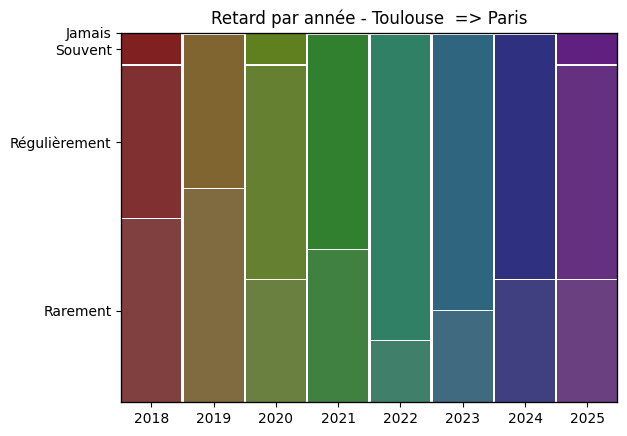

<Figure size 3000x1600 with 0 Axes>

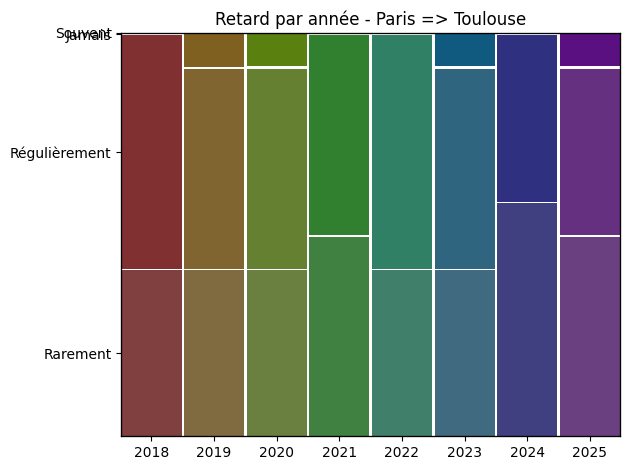

In [24]:
# Extract year from date for both dataframes
toulouse_to_paris['year'] = toulouse_to_paris['date'].str[:4]
paris_to_toulouse['year'] = paris_to_toulouse['date'].str[:4]

# Toulouse to paris
# Convertir 'retard' en catégorie ordonnée
toulouse_to_paris['retard'] = pd.Categorical(
       toulouse_to_paris['retard'],
       categories=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
       ordered=True
)

# Créer le mosaic plot
plt.figure(figsize=(30, 16))
mosaic(toulouse_to_paris, ['year', 'retard'], 
          title='Retard par année - Toulouse  => Paris',
          labelizer=lambda k: "")

#Paris to Toulouse
#convertir 'retard' en catégorie ordonnée
paris_to_toulouse['retard'] = pd.Categorical(
       paris_to_toulouse['retard'],
       categories=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
       ordered=True
)

#Creer le mosaic plot
plt.figure(figsize=(30, 16))
mosaic(paris_to_toulouse, ['year', 'retard'], 
          title='Retard par année - Paris => Toulouse',
          labelizer=lambda k: "")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

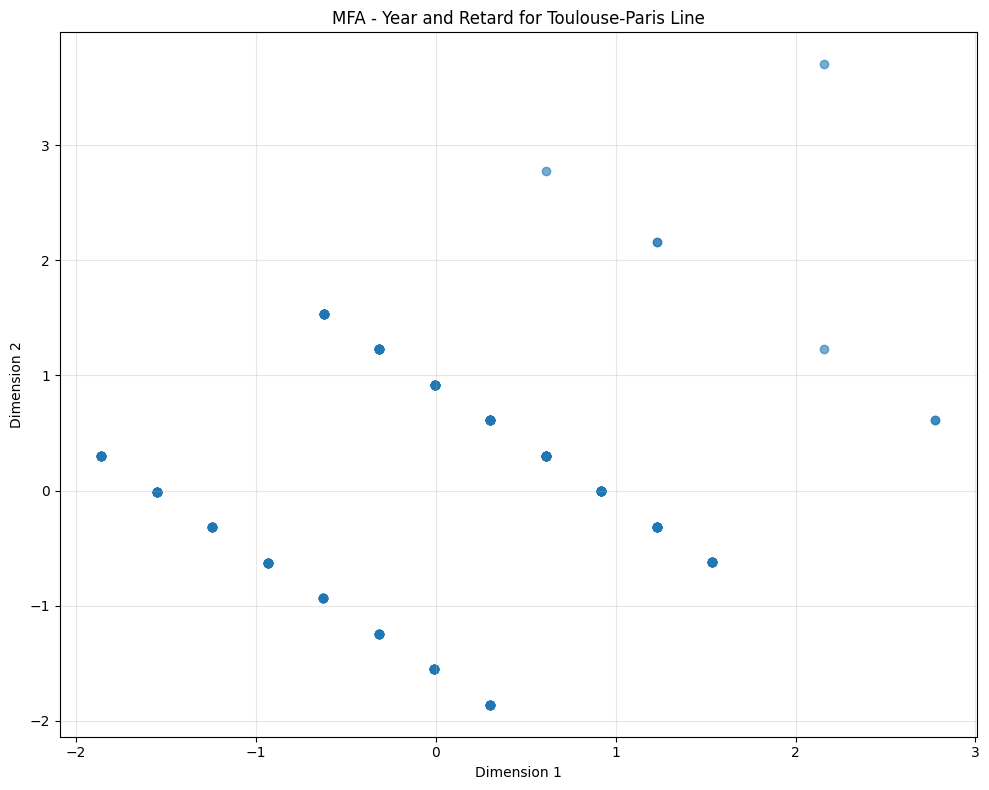

In [ ]:
# Prepare data for MFA - select qualitative variables
mfa_data = toulouse_paris[['year', 'retard']].copy()

# Encode categorical variables to numerical
mfa_data_encoded = mfa_data.copy()
mfa_data_encoded['year'] = pd.factorize(mfa_data_encoded['year'])[0]
mfa_data_encoded['retard'] = pd.factorize(mfa_data_encoded['retard'])[0]

# Define groups (each variable is its own group for MFA)
groups = {'year': ['year'], 'retard': ['retard']}

# Fit MFA with groups parameter
mfa = prince.MFA(
    n_components=2,
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42
)

mfa.fit(mfa_data_encoded, groups=groups)

# Plot the MFA results using row_coordinates
row_coords = mfa.row_coordinates(mfa_data_encoded)

plt.figure(figsize=(10, 8))
plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], alpha=0.6)
plt.xlabel(f'Dimension 1')
plt.ylabel(f'Dimension 2')
plt.title('MFA - Year and Retard for Toulouse-Paris Line')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

